# 1-Month Direction Classifier — Model Evaluation Notebook

## Overview

This notebook trains and evaluates **one candidate machine learning model** for predicting the 1-month direction of stock prices (buy / hold / sell) using a prepared, feature-engineered dataset.

**Inputs:** A single Parquet file produced by the data-preparation notebook (`2_prepare_data/prepared_dataset.parquet`), containing per-symbol daily rows with all engineered features and a 3-class direction label.

**Outputs:**
- Validation and test performance metrics (macro F1, weighted F1, balanced accuracy, per-class precision/recall/F1, confusion matrices).
- A standardized JSON artifact (`3_evaluate_model/{MODEL_NAME}_metrics.json`) for downstream multi-model comparison.
- Optional: test-set prediction CSV and pickled model.

**Design principle — template notebook:** This notebook is structured so that duplicating it and editing only the configuration cell (Section 2.1) and the model definition cell (Section 7.1) is sufficient to evaluate any of the 5–6 candidate classifiers. All output file names are derived automatically from `MODEL_NAME`.

**Leakage guarantee:** Data splitting is strictly chronological. No validation or test data is ever passed to any `fit` call.

# 2. Configuration and Imports

## 2.1 Notebook Configuration and Model Identifier

This cell defines **all user-facing configuration** for the notebook. It is the only cell that must be edited when adapting this template for a different model.

Configure the following variables:
- `DATASET_PATH` — absolute or project-relative path to the prepared Parquet file (default: `1-month-direction-classifier/2_prepare_data/prepared_dataset.parquet`).
- `OUTPUT_DIR` — directory where all evaluation artifacts will be written (default: `1-month-direction-classifier/3_evaluate_model`).
- `MODEL_NAME` — identifier string used in all output file names (e.g. `mlp_classifier_baseline`). Must be filesystem-safe (no spaces or special characters).
- `RANDOM_SEED` — integer seed for reproducibility in any stochastic components.
- `SAVE_PREDICTIONS_CSV` — boolean toggle to control whether a per-row prediction CSV is written.
- `SAVE_MODEL_PICKLE` — boolean toggle to control whether the trained pipeline is pickled to disk.

**Output:** Named variables available to all subsequent cells.

In [1]:
from pathlib import Path

# ?? Paths ??????????????????????????????????????????????????????????????????
DATASET_PATH = Path(
    r'c:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python'
    r'\1‑month-direction-classifier\2_prepare_data\prepared_dataset.parquet'
)
OUTPUT_DIR = Path(
    r'c:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python'
    r'\1‑month-direction-classifier\3_evaluate_model'
)

# ?? Model identity ?????????????????????????????????????????????????????????
MODEL_NAME = 'mlp_classifier_baseline'

# ?? Reproducibility ????????????????????????????????????????????????????????
RANDOM_SEED = 42

# ?? Optional artifact toggles ??????????????????????????????????????????????
SAVE_PREDICTIONS_CSV = True
SAVE_MODEL_PICKLE    = True

print(f'DATASET_PATH        : {DATASET_PATH}')
print(f'OUTPUT_DIR          : {OUTPUT_DIR}')
print(f'MODEL_NAME          : {MODEL_NAME}')
print(f'RANDOM_SEED         : {RANDOM_SEED}')
print(f'SAVE_PREDICTIONS_CSV: {SAVE_PREDICTIONS_CSV}')
print(f'SAVE_MODEL_PICKLE   : {SAVE_MODEL_PICKLE}')


DATASET_PATH        : c:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python\1‑month-direction-classifier\2_prepare_data\prepared_dataset.parquet
OUTPUT_DIR          : c:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python\1‑month-direction-classifier\3_evaluate_model
MODEL_NAME          : mlp_classifier_baseline
RANDOM_SEED         : 42
SAVE_PREDICTIONS_CSV: True
SAVE_MODEL_PICKLE   : True


## 2.2 Library Imports

Import all libraries required by this notebook in a single cell so dependency issues surface immediately.

Import:
- Data manipulation: `pandas`, `numpy`.
- Serialization and utilities: `json`, `pickle`, `time`, `warnings`, `datetime`.
- Plotting: `matplotlib.pyplot`, `seaborn`.
- scikit-learn components:
    - `metrics`: `f1_score`, `balanced_accuracy_score`, `classification_report`, `confusion_matrix`.
  - `pipeline`: `Pipeline`.
    - `preprocessing`: `StandardScaler`.
    - Estimators: `MLPClassifier`.
  - `dummy`: `DummyClassifier` (for the baseline).

> **Note:** `pathlib.Path` is imported in the configuration cell (Section 2.1) and is therefore available here without re-importing.

**Output:** All symbols available in the notebook namespace. Any `ImportError` surfaces here before any data is loaded.

In [29]:
import json
import pickle
import time
import warnings
import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier

print('All imports successful.')


All imports successful.


# 3. Load and Validate Dataset

## 3.1 Load Parquet into `df_raw`

Reads the prepared dataset from the path defined by `DATASET_PATH` into a Pandas DataFrame named `df_raw`.

- Use `pandas.read_parquet`.
- After loading, parse the `date` column to `datetime64` if it is not already in that dtype.
- Sort the DataFrame by `date` ascending (then `symbol` for stability) as a defensive step before any downstream operation.

**Input:** `DATASET_PATH` (configuration variable).  
**Output:** `df_raw` — full dataset DataFrame, date-sorted.

In [5]:
df_raw = pd.read_parquet(DATASET_PATH)

if not pd.api.types.is_datetime64_any_dtype(df_raw['date']):
    df_raw['date'] = pd.to_datetime(df_raw['date'])

df_raw = df_raw.sort_values(['date', 'symbol']).reset_index(drop=True)

print(f'Loaded df_raw: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Date range   : {df_raw["date"].min().date()} -> {df_raw["date"].max().date()}')
print(f'date dtype   : {df_raw["date"].dtype}')


Loaded df_raw: 3,867 rows x 49 columns
Date range   : 2021-02-01 -> 2026-03-19
date dtype   : datetime64[ns]


## 3.2 Schema and Dtype Validation

Verifies that `df_raw` contains all columns required by the PRD before any processing begins.

- Define the following lists:
  - `RAW_COLS` — the 8 raw OHLCV columns: `symbol`, `date`, `open`, `high`, `low`, `close`, `adj_close`, `volume`.
  - `FEATURE_COLS` — all 39 engineered feature columns (from `ret_1d` through `dist_from_20d_low`).
  - `TARGET_COLS` — `fwd_ret_20d` and `label`.
- Check that every column in `RAW_COLS + FEATURE_COLS + TARGET_COLS` is present in `df_raw.columns`.
- Confirm that the `date` column dtype is `datetime64[ns]` (or equivalent).
- Confirm that `label` contains only values from `{"buy", "hold", "sell"}` (ignoring NaN rows which will be dropped later).
- Raise a descriptive `ValueError` listing any missing columns or unexpected dtypes so the issue surfaces clearly before training.

**Input:** `df_raw`.  
**Output:** Printed confirmation message if all checks pass; `ValueError` otherwise.

In [6]:
RAW_COLS = ['symbol', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

FEATURE_COLS = [
    # Returns
    'ret_1d', 'log_ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d',
    'log_ret_5d', 'log_ret_20d',
    # Range
    'tr_range', 'true_range',
    # Moving averages
    'sma_5', 'sma_20', 'sma_50', 'sma_200',
    # Price relative to MA
    'close_over_sma_20', 'close_over_sma_50', 'close_over_sma_200',
    # MA momentum
    'sma_20_slope_5d', 'sma_50_slope_5d',
    # Volatility
    'vol_ret_5d', 'vol_ret_20d', 'vol_ret_60d', 'vol_tr_5d', 'vol_tr_20d',
    # Volume
    'value_traded', 'vol_ma_20', 'vol_ma_60', 'vol_rel_20',
    'value_traded_ma_20', 'value_traded_rel_20',
    # Momentum / oscillators
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    # Trend
    'atr_14',
    # Price extremes
    'hh_20d', 'll_20d', 'dist_from_20d_high', 'dist_from_20d_low',
]

TARGET_COLS = ['fwd_ret_20d', 'label']

required = RAW_COLS + FEATURE_COLS + TARGET_COLS
missing_cols = [c for c in required if c not in df_raw.columns]

if missing_cols:
    raise ValueError(
        f'Missing {len(missing_cols)} required column(s):\n  {missing_cols}\n'
        f'Available columns: {df_raw.columns.tolist()}'
    )

if not pd.api.types.is_datetime64_any_dtype(df_raw['date']):
    raise ValueError(f"Column 'date' has unexpected dtype: {df_raw['date'].dtype}")

valid_labels = {'buy', 'hold', 'sell'}
unexpected_labels = set(df_raw['label'].dropna().unique()) - valid_labels
if unexpected_labels:
    raise ValueError(f'Unexpected label values found: {unexpected_labels}')

print('All required columns present.')
print(f'date dtype  : {df_raw["date"].dtype}')
print(f'label values: {sorted(df_raw["label"].dropna().unique())}')
print(f'Total required columns checked: {len(required)}')


All required columns present.
date dtype  : datetime64[ns]
label values: ['buy', 'hold', 'sell']
Total required columns checked: 49


## 3.3 Basic Dataset Diagnostics

Prints a compact summary to confirm the dataset is consistent with expectations before proceeding to modeling.

Report:
- Overall shape (`n_rows`, `n_columns`).
- Date range: earliest and latest `date` values.
- Number of unique symbols.
- Label value counts and relative frequencies (to surface class imbalance early).
- Count of NaN values per column (summary: total NaN cells, columns with any NaN, and the 5 columns with the most NaN values).

**Input:** `df_raw`.  
**Output:** Printed summary table(s) — no new variables created.

In [7]:
n_rows, n_cols = df_raw.shape
print('=' * 55)
print('DATASET DIAGNOSTICS')
print('=' * 55)
print(f'Shape          : {n_rows:,} rows x {n_cols} columns')
print(f'Date range     : {df_raw["date"].min().date()} -> {df_raw["date"].max().date()}')
print(f'Unique symbols : {df_raw["symbol"].nunique()}')

print('\n-- Label distribution --')
label_counts = df_raw['label'].value_counts(dropna=False)
label_pct    = df_raw['label'].value_counts(normalize=True, dropna=False) * 100
print(pd.DataFrame({'count': label_counts, 'pct (%)': label_pct.round(2)}).to_string())

print('\n-- NaN summary --')
nan_per_col   = df_raw.isnull().sum()
total_nans    = nan_per_col.sum()
cols_with_nan = (nan_per_col > 0).sum()
print(f'Total NaN cells  : {total_nans:,}')
print(f'Columns with NaN : {cols_with_nan} / {n_cols}')
if cols_with_nan > 0:
    print('\nTop-5 columns by NaN count:')
    print(nan_per_col[nan_per_col > 0].sort_values(ascending=False).head(5).to_string())
print('=' * 55)


DATASET DIAGNOSTICS
Shape          : 3,867 rows x 49 columns
Date range     : 2021-02-01 -> 2026-03-19
Unique symbols : 3

-- Label distribution --
      count  pct (%)
hold   1412    36.51
buy    1325    34.26
sell   1130    29.22

-- NaN summary --
Total NaN cells  : 0
Columns with NaN : 0 / 49


# 4. Feature and Target Selection

## 4.1 Define Feature Columns, Target, and Metadata

Explicitly separates the dataset into the feature matrix `X`, target series `y`, and a metadata frame `meta`.

- Define `FEATURE_LIST` as all engineered feature columns excluding `fwd_ret_20d`, `label`, `symbol`, and `date`. This list should be derived programmatically from `FEATURE_COLS` to avoid hardcoding and to stay in sync with the validated column set.
- Create:
  - `X` — DataFrame of shape `(n_rows, n_features)` containing only the columns in `FEATURE_LIST`.
  - `y` — Series containing the `label` column.
  - `meta` — DataFrame containing `symbol` and `date`, kept for later use in prediction output and error analysis.

**Input:** `df_raw`, `FEATURE_COLS` list.  
**Output:** `X`, `y`, `meta`, `FEATURE_LIST`.

In [8]:
exclude = set(RAW_COLS + TARGET_COLS)
FEATURE_LIST = [c for c in FEATURE_COLS if c not in exclude]

X    = df_raw[FEATURE_LIST].copy()
y    = df_raw['label'].copy()
meta = df_raw[['symbol', 'date']].copy()

print(f'FEATURE_LIST : {len(FEATURE_LIST)} features')
print(f'X shape      : {X.shape}')
print(f'y shape      : {y.shape}')
print(f'meta shape   : {meta.shape}')


FEATURE_LIST : 39 features
X shape      : (3867, 39)
y shape      : (3867,)
meta shape   : (3867, 2)


## 4.2 Drop Rows with Invalid Labels or Missing Features

Removes any rows that would cause training or evaluation errors.

- Drop rows where `y` is NaN or where the label value is not in `{"buy", "hold", "sell"}`.
- Drop rows where any column in `X` contains NaN.
- Apply identical row masks to `X`, `y`, and `meta` so all three remain aligned.
- After dropping, print:
  - Number of rows removed and percentage of the original dataset.
  - Remaining total row count.
  - Remaining class distribution for `y` (counts and percentages).

**Input:** `X`, `y`, `meta`.  
**Output:** Cleaned and index-reset `X`, `y`, `meta` with consistent row alignment.

In [9]:
n_original = len(y)
valid_labels = {'buy', 'hold', 'sell'}

label_mask   = y.isin(valid_labels)
feature_mask = X.notna().all(axis=1)
keep_mask    = label_mask & feature_mask

X    = X[keep_mask].reset_index(drop=True)
y    = y[keep_mask].reset_index(drop=True)
meta = meta[keep_mask].reset_index(drop=True)

n_removed = n_original - len(y)
print(f'Rows removed  : {n_removed:,} ({n_removed / n_original * 100:.2f}% of original)')
print(f'Rows remaining: {len(y):,}')
print('\n-- Class distribution after cleaning --')
counts = y.value_counts()
pcts   = y.value_counts(normalize=True) * 100
print(pd.DataFrame({'count': counts, 'pct (%)': pcts.round(2)}).to_string())


Rows removed  : 0 (0.00% of original)
Rows remaining: 3,867

-- Class distribution after cleaning --
      count  pct (%)
hold   1412    36.51
buy    1325    34.26
sell   1130    29.22


# 5. Time-Aware Train / Validation / Test Split

## 5.1 Define Chronological Splits

Splits the dataset into three non-overlapping time windows using calendar dates. No shuffling is applied at any point.

- Determine the full date range: `date_min` and `date_max` from `meta["date"]`.
- Compute split boundary dates using a 70 / 15 / 15 ratio over the total number of calendar days in the span:
  - `train_end_date` — last date of the training window (~70%).
  - `val_end_date` — last date of the validation window (~85% cumulative).
  - `test_start_date` and `test_end_date` — first and last dates of the test window.
- Apply boolean masks based on `meta["date"]` to produce six arrays:
  - `X_train`, `y_train` — rows where `date <= train_end_date`.
  - `X_val`, `y_val` — rows where `train_end_date < date <= val_end_date`.
  - `X_test`, `y_test` — rows where `date > val_end_date`.
- Also split `meta` into `meta_train`, `meta_val`, `meta_test` for later use.
- Print the actual boundary dates, not just the target fractions.

**Input:** `X`, `y`, `meta`, split ratio constants.  
**Output:** `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`, `meta_train`, `meta_val`, `meta_test`, and boundary date variables (`train_end_date`, `val_end_date`).

In [10]:
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

date_min   = meta['date'].min()
date_max   = meta['date'].max()
total_days = (date_max - date_min).days

train_end_date = date_min + pd.Timedelta(days=int(total_days * TRAIN_FRAC))
val_end_date   = date_min + pd.Timedelta(days=int(total_days * (TRAIN_FRAC + VAL_FRAC)))

train_mask = meta['date'] <= train_end_date
val_mask   = (meta['date'] > train_end_date) & (meta['date'] <= val_end_date)
test_mask  = meta['date'] > val_end_date

X_train, y_train, meta_train = X[train_mask].reset_index(drop=True), y[train_mask].reset_index(drop=True), meta[train_mask].reset_index(drop=True)
X_val,   y_val,   meta_val   = X[val_mask].reset_index(drop=True),   y[val_mask].reset_index(drop=True),   meta[val_mask].reset_index(drop=True)
X_test,  y_test,  meta_test  = X[test_mask].reset_index(drop=True),  y[test_mask].reset_index(drop=True),  meta[test_mask].reset_index(drop=True)

test_start_date = meta_test['date'].min() if len(meta_test) > 0 else None
test_end_date   = meta_test['date'].max() if len(meta_test) > 0 else None

print('-- Chronological split boundaries --')
print(f'Full range  : {date_min.date()} -> {date_max.date()}  ({total_days} calendar days)')
print(f'Train end   : {train_end_date.date()}')
print(f'Val end     : {val_end_date.date()}')
print(f'Test start  : {test_start_date.date() if test_start_date else "N/A"}')
print(f'Test end    : {test_end_date.date() if test_end_date else "N/A"}')
print(f'\nRow counts -> train: {len(X_train):,}  val: {len(X_val):,}  test: {len(X_test):,}')


-- Chronological split boundaries --
Full range  : 2021-02-01 -> 2026-03-19  (1872 calendar days)
Train end   : 2024-09-03
Val end     : 2025-06-11
Test start  : 2025-06-12
Test end    : 2026-03-19

Row counts -> train: 2,709  val: 579  test: 579


## 5.2 Split Sanity Checks

Validates that the splits are well-formed and surfaces any issues before training begins.

Checks to perform:
- Assert that no date value appears in more than one split (zero overlap between train/val/test date ranges).
- Print the row count for each split and verify none is empty.
- Print class label distribution (counts and percentages) for `y_train`, `y_val`, and `y_test` side by side to expose any split-level class imbalance or distributional shift.
- Print the fraction of the total dataset in each split (sanity check for approximate 70/15/15 ratio).

**Input:** `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `meta_train`, `meta_val`, `meta_test`.  
**Output:** Printed confirmation and class-distribution table; `AssertionError` with a description if any date overlap is detected.

In [11]:
total = len(X_train) + len(X_val) + len(X_test)

train_dates = set(meta_train['date'])
val_dates   = set(meta_val['date'])
test_dates  = set(meta_test['date'])

assert len(train_dates & val_dates)   == 0, 'Overlap detected between train and val date sets!'
assert len(train_dates & test_dates)  == 0, 'Overlap detected between train and test date sets!'
assert len(val_dates   & test_dates)  == 0, 'Overlap detected between val and test date sets!'
print('No date overlap between splits.')

for name, ds in [('train', X_train), ('val', X_val), ('test', X_test)]:
    assert len(ds) > 0, f"Split '{name}' is empty!"
print('All splits are non-empty.')

print('\n-- Split sizes --')
for name, ds in [('train', X_train), ('val', X_val), ('test', X_test)]:
    print(f'  {name:<6}: {len(ds):>7,} rows  ({len(ds)/total*100:.1f}%)')

print('\n-- Class distribution per split --')
classes = ['buy', 'hold', 'sell']
header = f'{"class":<8} {"train_n":>8} {"train_%":>8} {"val_n":>8} {"val_%":>8} {"test_n":>8} {"test_%":>8}'
print(header)
print('-' * len(header))
for cls in classes:
    tr_n = (y_train == cls).sum(); tr_p = tr_n / len(y_train) * 100
    v_n  = (y_val   == cls).sum(); v_p  = v_n  / len(y_val)   * 100
    te_n = (y_test  == cls).sum(); te_p = te_n / len(y_test)  * 100
    print(f'  {cls:<6} {tr_n:>8,} {tr_p:>7.1f}% {v_n:>8,} {v_p:>7.1f}% {te_n:>8,} {te_p:>7.1f}%')


No date overlap between splits.
All splits are non-empty.

-- Split sizes --
  train :   2,709 rows  (70.1%)
  val   :     579 rows  (15.0%)
  test  :     579 rows  (15.0%)

-- Class distribution per split --
class     train_n  train_%    val_n    val_%   test_n   test_%
--------------------------------------------------------------
  buy         943    34.8%      203    35.1%      179    30.9%
  hold        932    34.4%      211    36.4%      269    46.5%
  sell        834    30.8%      165    28.5%      131    22.6%


# 6. Baseline Classifier

## 6.1 Define and Train the Majority-Class Baseline

Establishes the trivial reference point against which all candidate models will be compared.

- Use scikit-learn's `DummyClassifier` with `strategy="most_frequent"` as the baseline. This always predicts the majority class observed in the training set.
- Fit the baseline on `X_train` and `y_train`.
- Print which class the baseline will always predict (the majority class in `y_train`).

> **Note:** The PRD lists additional baseline options (always-hold, rule-based on `ret_20d`). The majority-class `DummyClassifier` is used here as the primary baseline because it is data-driven and fits within the standard scikit-learn evaluation flow. Implementing the rule-based alternative is optional and can be added in a future cell.

**Input:** `X_train`, `y_train`.  
**Output:** Fitted `baseline_clf` object.

In [12]:
baseline_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
baseline_clf.fit(X_train, y_train)

majority_class = y_train.mode()[0]
print(f'Baseline strategy : most_frequent')
print(f'Majority class    : "{majority_class}"  (this is what the baseline always predicts)')


Baseline strategy : most_frequent
Majority class    : "buy"  (this is what the baseline always predicts)


## 6.2 Evaluate Baseline on Validation and Test Sets

Produces a full metric set for the baseline on both validation and test sets, stored in a dict for later inclusion in the standardized result artifact.

For each split (validation and test):
- Generate predictions using `baseline_clf.predict(X_split)`.
- Compute:
  - Macro F1 (`f1_score` with `average="macro"`).
  - Weighted F1 (`f1_score` with `average="weighted"`).
  - Balanced accuracy (`balanced_accuracy_score`).
  - Per-class precision, recall, and F1 for `buy`, `hold`, `sell` via `classification_report`.
  - Confusion matrix as a 2D list.
- Store all metrics in `baseline_results` dict with the structure:
  ```
  baseline_results = {
      "val":  { "macro_f1": ..., "weighted_f1": ..., "balanced_accuracy": ..., "per_class": {...}, "confusion_matrix": [...] },
      "test": { ... }
  }
  ```
- Print a human-readable summary table for quick inspection.

**Input:** Fitted `baseline_clf`, `X_val`, `y_val`, `X_test`, `y_test`.  
**Output:** `baseline_results` dict and printed metric summary.

In [13]:
def _compute_metrics(y_true, y_pred):
    classes = ['buy', 'hold', 'sell']
    report  = classification_report(y_true, y_pred, labels=classes,
                                    output_dict=True, zero_division=0)
    cm      = confusion_matrix(y_true, y_pred, labels=classes).tolist()
    per_class = {
        cls: {
            'precision': round(report[cls]['precision'], 4),
            'recall':    round(report[cls]['recall'],    4),
            'f1':        round(report[cls]['f1-score'],  4),
        }
        for cls in classes
    }
    return {
        'macro_f1':          round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'weighted_f1':       round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_true, y_pred), 4),
        'per_class':         per_class,
        'confusion_matrix':  cm,
    }

baseline_results = {
    'val':  _compute_metrics(y_val,  baseline_clf.predict(X_val)),
    'test': _compute_metrics(y_test, baseline_clf.predict(X_test)),
}

print(f'{"Metric":<22} {"Val":>8} {"Test":>8}')
print('-' * 42)
for key in ['macro_f1', 'weighted_f1', 'balanced_accuracy']:
    print(f'  {key:<20} {baseline_results["val"][key]:>8.4f} {baseline_results["test"][key]:>8.4f}')
print('\nPer-class F1 (val / test):')
for cls in ['buy', 'hold', 'sell']:
    vf1 = baseline_results['val']['per_class'][cls]['f1']
    tf1 = baseline_results['test']['per_class'][cls]['f1']
    print(f'  {cls:<6}  val={vf1:.4f}  test={tf1:.4f}')


Metric                      Val     Test
------------------------------------------
  macro_f1               0.1731   0.1574
  weighted_f1            0.1820   0.1460
  balanced_accuracy      0.3333   0.3333

Per-class F1 (val / test):
  buy     val=0.5192  test=0.4723
  hold    val=0.0000  test=0.0000
  sell    val=0.0000  test=0.0000


# 7. Model Definition and Training

## 7.1 Choose and Configure the Candidate Model

**This is the primary cell to edit when adapting this notebook for a different candidate model** (alongside the `MODEL_NAME` variable in Section 2.1).

Define the model configuration:
- Instantiate the chosen estimator (default for this template: `MLPClassifier`) with explicit keyword arguments for all non-default hyperparameters, including `random_state`.
- Set `class_weight` strategy where applicable. For `MLPClassifier`, which does not have a `class_weight` parameter, document the alternative approach of handling imbalance via macro F1 / balanced accuracy while keeping the training procedure unchanged.
- Store key hyperparameter values in a `MODEL_HYPERPARAMS` dict for later inclusion in the result artifact.
- Print a summary of the model class and all configured hyperparameters.

**Input:** Configuration constants (`RANDOM_SEED`).  
**Output:** Instantiated (unfitted) estimator object and `MODEL_HYPERPARAMS` dict.

In [14]:
estimator = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=64,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=False,
    random_state=RANDOM_SEED,
)

MODEL_HYPERPARAMS = {
    'hidden_layer_sizes': (64, 32),
    'activation':         'relu',
    'solver':             'adam',
    'alpha':              0.001,
    'batch_size':         64,
    'learning_rate_init': 0.001,
    'max_iter':           500,
    'early_stopping':     False,
    'random_state':       RANDOM_SEED,
    'class_weight':       'n/a - MLPClassifier does not support class_weight; monitor macro F1 and balanced accuracy',
}

print(f'Model class : {estimator.__class__.__module__}.{estimator.__class__.__name__}')
print('\nConfigured hyperparameters:')
for k, v in MODEL_HYPERPARAMS.items():
    print(f'  {k:<22} = {v}')


Model class : sklearn.neural_network._multilayer_perceptron.MLPClassifier

Configured hyperparameters:
  hidden_layer_sizes     = (64, 32)
  activation             = relu
  solver                 = adam
  alpha                  = 0.001
  batch_size             = 64
  learning_rate_init     = 0.001
  max_iter               = 500
  early_stopping         = False
  random_state           = 42
  class_weight           = n/a - MLPClassifier does not support class_weight; monitor macro F1 and balanced accuracy


## 7.2 Build the Preprocessing Pipeline

Wraps the estimator inside a scikit-learn `Pipeline` to ensure that any preprocessing is applied consistently and without leakage.

- Determine whether the chosen model requires feature scaling:
  - **Requires scaling** (Logistic Regression, LinearSVC, MLPClassifier): include a `StandardScaler` step as the first pipeline stage.
  - **Does not require scaling** (tree-based models: RandomForest, ExtraTrees, HistGradientBoosting): pipeline contains only the estimator step.
- For this template (MLPClassifier): create `Pipeline([("scaler", StandardScaler()), ("clf", estimator)])` so the neural network sees standardized inputs.
- Print the pipeline steps to confirm the structure.

> **Note:** If `StandardScaler` is included, it will be fitted exclusively on `X_train` during the `pipeline.fit` call — never on validation or test data. This is enforced automatically by the Pipeline.

**Input:** Instantiated estimator.  
**Output:** `pipeline` — unfitted `Pipeline` object.

In [15]:
# MLPClassifier benefits from standardized inputs
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', estimator),
])

print('Pipeline steps:')
for step_name, step_obj in pipeline.steps:
    print(f'  [{step_name}]  {step_obj.__class__.__name__}')


Pipeline steps:
  [scaler]  StandardScaler
  [clf]  MLPClassifier


## 7.3 Fit the Pipeline on the Training Set

Trains the full pipeline on `X_train` and `y_train` and records diagnostic information.

- Record wall-clock time before and after `pipeline.fit` to compute approximate training duration.
- Call `pipeline.fit(X_train, y_train)`.
- Print:
  - Training duration in seconds.
  - A confirmation that fitting completed successfully.
  - Any convergence warnings or other `ConvergenceWarning` messages that appear during fitting (note: these will surface automatically from scikit-learn; document whether they appeared or not).

**Input:** `pipeline`, `X_train`, `y_train`.  
**Output:** Fitted `pipeline` object; printed training time.

In [16]:
t0 = time.perf_counter()

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter('always')
    pipeline.fit(X_train, y_train)

t1 = time.perf_counter()
training_seconds = t1 - t0

convergence_warnings = [
    w for w in caught_warnings
    if 'ConvergenceWarning' in str(w.category)
]

print(f'Fitting completed in {training_seconds:.2f} seconds.')
if convergence_warnings:
    print(f'  {len(convergence_warnings)} ConvergenceWarning(s) detected during fitting.')
    for w in convergence_warnings:
        print(f'    {w.message}')
else:
    print('  No ConvergenceWarning messages during fitting.')


Fitting completed in 2.46 seconds.
  No ConvergenceWarning messages during fitting.


# 8. Validation Performance and Diagnostics

## 8.1 Predictions on the Validation Set

Uses the fitted pipeline to produce class label predictions and, where available, class probability estimates for the validation set.

- Call `pipeline.predict(X_val)` to produce `y_val_pred`.
- Attempt `pipeline.predict_proba(X_val)` to produce `y_val_proba`. If the estimator does not support `predict_proba` (e.g. `LinearSVC`), catch the `AttributeError` gracefully, set `y_val_proba = None`, and print a note.

**Input:** Fitted `pipeline`, `X_val`.  
**Output:** `y_val_pred` (array of predicted labels), `y_val_proba` (probability array or `None`).

In [17]:
y_val_pred = pipeline.predict(X_val)

try:
    y_val_proba = pipeline.predict_proba(X_val)
    print(f'predict_proba available. Shape: {y_val_proba.shape}  |  class order: {pipeline.classes_.tolist()}')
except AttributeError:
    y_val_proba = None
    print('Note: estimator does not support predict_proba. y_val_proba set to None.')


predict_proba available. Shape: (579, 3)  |  class order: ['buy', 'hold', 'sell']


## 8.2 Compute Validation Metrics

Computes the full standardized metric set on the validation predictions and stores results in `val_metrics`.

Compute:
- Macro F1 (`average="macro"`, `zero_division=0`).
- Weighted F1 (`average="weighted"`, `zero_division=0`).
- Balanced accuracy.
- Per-class precision, recall, and F1 for each of `buy`, `hold`, `sell` — extracted from `classification_report(output_dict=True)`.
- Confusion matrix as a 2D Python list (converting from numpy array), with rows and columns ordered as `["buy", "hold", "sell"]`.

Store all values in `val_metrics` using the schema:
```
val_metrics = {
    "macro_f1": float,
    "weighted_f1": float,
    "balanced_accuracy": float,
    "per_class": {
        "buy":  {"precision": float, "recall": float, "f1": float},
        "hold": {"precision": float, "recall": float, "f1": float},
        "sell": {"precision": float, "recall": float, "f1": float},
    },
    "confusion_matrix": [[int, ...], ...]
}
```
Print a formatted summary comparing model metrics against baseline metrics side by side.

**Input:** `y_val`, `y_val_pred`, `baseline_results["val"]`.  
**Output:** `val_metrics` dict and printed comparison table.

In [18]:
classes = ['buy', 'hold', 'sell']

def _build_metrics_dict(y_true, y_pred):
    report = classification_report(y_true, y_pred, labels=classes,
                                   output_dict=True, zero_division=0)
    return {
        'macro_f1':          round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'weighted_f1':       round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_true, y_pred), 4),
        'per_class': {
            cls: {
                'precision': round(report[cls]['precision'], 4),
                'recall':    round(report[cls]['recall'],    4),
                'f1':        round(report[cls]['f1-score'],  4),
            }
            for cls in classes
        },
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=classes).tolist(),
    }

val_metrics = _build_metrics_dict(y_val, y_val_pred)

bv = baseline_results['val']
print(f'{"Metric":<24} {"Baseline (val)":>15} {"Model (val)":>12}')
print('-' * 54)
for key in ['macro_f1', 'weighted_f1', 'balanced_accuracy']:
    print(f'  {key:<22} {bv[key]:>15.4f} {val_metrics[key]:>12.4f}')
print('\nPer-class F1:')
for cls in classes:
    bf1 = bv['per_class'][cls]['f1']
    mf1 = val_metrics['per_class'][cls]['f1']
    delta = mf1 - bf1
    print(f'  {cls:<6}  baseline={bf1:.4f}  model={mf1:.4f}  delta={delta:+.4f}')


Metric                    Baseline (val)  Model (val)
------------------------------------------------------
  macro_f1                        0.1731       0.3398
  weighted_f1                     0.1820       0.3470
  balanced_accuracy               0.3333       0.3478

Per-class F1:
  buy     baseline=0.5192  model=0.4662  delta=-0.0530
  hold    baseline=0.0000  model=0.3269  delta=+0.3269
  sell    baseline=0.0000  model=0.2261  delta=+0.2261


## 8.3 Validation Diagnostic Plots

Produces inline plots to support interpretation of the validation results. These are visual diagnostics only and are not written to the output directory.

**Plot 1 — Normalized confusion matrix heatmap:**
- Display the confusion matrix as a seaborn heatmap with row normalization (true-label proportions).
- Use `["buy", "hold", "sell"]` as axis tick labels.
- Add title including `MODEL_NAME` and the validation date range.

**Plot 2 — Class-wise F1 bar chart:**
- Display a grouped bar chart comparing per-class F1 scores for the model vs the baseline on the validation set.
- Include `buy`, `hold`, and `sell` on the x-axis; F1 score on the y-axis.

**Input:** `y_val`, `y_val_pred`, `val_metrics`, `baseline_results["val"]`.  
**Output:** One inline figure containing two side-by-side subplots.

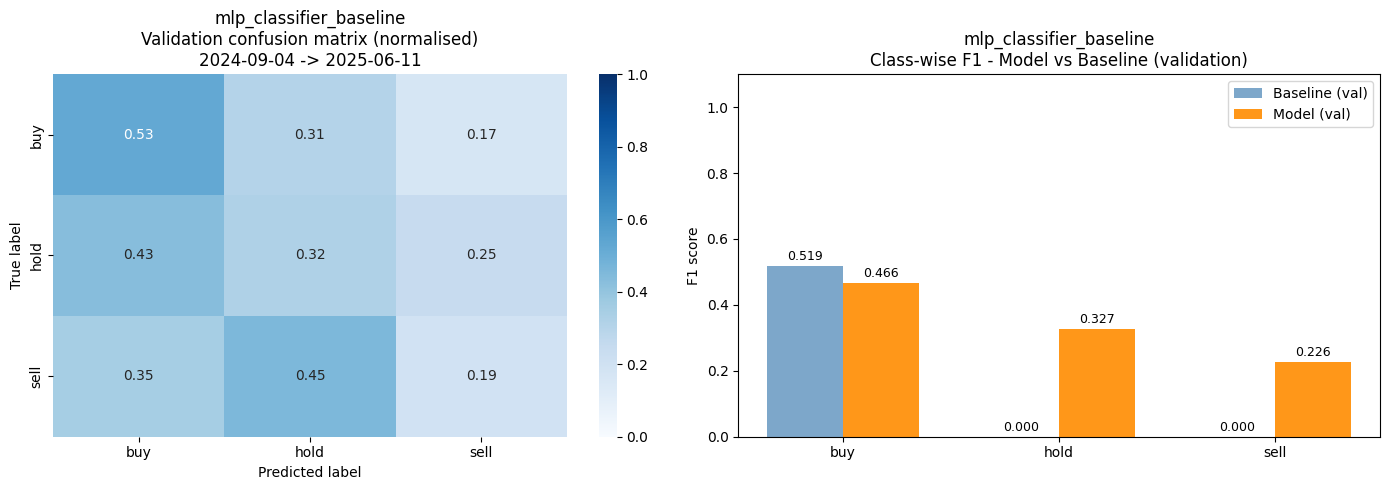

In [19]:
classes = ['buy', 'hold', 'sell']
val_start_str = meta_val['date'].min().date()
val_end_str   = meta_val['date'].max().date()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Normalised confusion matrix
cm_array = np.array(val_metrics['confusion_matrix'], dtype=float)
cm_norm  = cm_array / cm_array.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=classes, yticklabels=classes,
    vmin=0, vmax=1, ax=axes[0],
)
axes[0].set_title(f'{MODEL_NAME}\nValidation confusion matrix (normalised)\n{val_start_str} -> {val_end_str}')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Plot 2: Class-wise F1 bar chart
model_f1s    = [val_metrics['per_class'][c]['f1']              for c in classes]
baseline_f1s = [baseline_results['val']['per_class'][c]['f1'] for c in classes]
x = np.arange(len(classes))
width = 0.35
bars1 = axes[1].bar(x - width/2, baseline_f1s, width, label='Baseline (val)', color='steelblue', alpha=0.7)
bars2 = axes[1].bar(x + width/2, model_f1s,    width, label='Model (val)',    color='darkorange', alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_ylim(0, 1.10)
axes[1].set_ylabel('F1 score')
axes[1].set_title(f'{MODEL_NAME}\nClass-wise F1 - Model vs Baseline (validation)')
axes[1].legend()
axes[1].bar_label(bars1, fmt='%.3f', padding=2, fontsize=9)
axes[1].bar_label(bars2, fmt='%.3f', padding=2, fontsize=9)

plt.tight_layout()
plt.show()


# 9. Test Performance (Final Hold-Out Evaluation)

## 9.1 Final Fit Strategy — Option A (Train-Only Fit)

Documents and implements the chosen final evaluation strategy.

This notebook uses **Option A**: the pipeline is evaluated on the test set using the model already fitted on `X_train` only (from Section 7.3). No refit on the combined train+validation set is performed at this stage.

- Print a clear note that the test set is being evaluated against the train-only fit, and that Option B (refit on train+val) would be appropriate once hyperparameters are finalized for a selected model.
- No fitting or data transformation occurs in this cell — it is a documentation cell converted to code only to print the strategy confirmation.

**Input:** None (documentation cell).  
**Output:** Printed strategy note.

In [20]:
print('=' * 60)
print('FINAL EVALUATION STRATEGY - Option A (Train-only fit)')
print('=' * 60)
print(
    '\nThe pipeline was fitted exclusively on X_train (Section 7.3).\n'
    'The test set is now evaluated against that train-only fit.\n'
    '\nOption B - refit on train+val combined - would be appropriate\n'
    'once hyperparameters are finalised for a selected model and\n'
    'no further tuning decisions will be made based on test results.\n'
)


FINAL EVALUATION STRATEGY - Option A (Train-only fit)

The pipeline was fitted exclusively on X_train (Section 7.3).
The test set is now evaluated against that train-only fit.

Option B - refit on train+val combined - would be appropriate
once hyperparameters are finalised for a selected model and
no further tuning decisions will be made based on test results.



## 9.2 Predictions on the Test Set

Uses the already-fitted pipeline to predict labels and optionally probabilities on the hold-out test set.

- Call `pipeline.predict(X_test)` to produce `y_test_pred`.
- Attempt `pipeline.predict_proba(X_test)` to produce `y_test_proba`; set to `None` if unsupported.

**Input:** Fitted `pipeline`, `X_test`.  
**Output:** `y_test_pred`, `y_test_proba`.

In [21]:
y_test_pred = pipeline.predict(X_test)

try:
    y_test_proba = pipeline.predict_proba(X_test)
    print(f'predict_proba available. Shape: {y_test_proba.shape}  |  class order: {pipeline.classes_.tolist()}')
except AttributeError:
    y_test_proba = None
    print('Note: estimator does not support predict_proba. y_test_proba set to None.')


predict_proba available. Shape: (579, 3)  |  class order: ['buy', 'hold', 'sell']


## 9.3 Compute Test Metrics

Computes the same metric set as for validation on the test predictions and stores results in `test_metrics`.

- Apply identical computation logic as Section 8.2 to `y_test` and `y_test_pred`.
- Store in `test_metrics` using the same schema as `val_metrics`.
- Print a formatted summary comparing test metrics against baseline test metrics and against validation model metrics, so over-fitting or distributional shift can be spotted immediately.

**Input:** `y_test`, `y_test_pred`, `baseline_results["test"]`, `val_metrics`.  
**Output:** `test_metrics` dict and printed three-way comparison table (baseline / val / test).

In [22]:
test_metrics = _build_metrics_dict(y_test, y_test_pred)

bt = baseline_results['test']
print(f'{"Metric":<24} {"Baseline(test)":>15} {"Model(val)":>12} {"Model(test)":>12}')
print('-' * 66)
for key in ['macro_f1', 'weighted_f1', 'balanced_accuracy']:
    print(f'  {key:<22} {bt[key]:>15.4f} {val_metrics[key]:>12.4f} {test_metrics[key]:>12.4f}')
print('\nPer-class F1:')
for cls in ['buy', 'hold', 'sell']:
    bf1 = bt['per_class'][cls]['f1']
    vf1 = val_metrics['per_class'][cls]['f1']
    tf1 = test_metrics['per_class'][cls]['f1']
    print(f'  {cls:<6}  baseline={bf1:.4f}  model_val={vf1:.4f}  model_test={tf1:.4f}')


Metric                    Baseline(test)   Model(val)  Model(test)
------------------------------------------------------------------
  macro_f1                        0.1574       0.3398       0.3617
  weighted_f1                     0.1460       0.3470       0.3692
  balanced_accuracy               0.3333       0.3478       0.3786

Per-class F1:
  buy     baseline=0.4723  model_val=0.4662  model_test=0.4449
  hold    baseline=0.0000  model_val=0.3269  model_test=0.3640
  sell    baseline=0.0000  model_val=0.2261  model_test=0.2762


## 9.4 Test Set Diagnostic Plots

Produces the same set of diagnostic plots as Section 8.3, applied to the test set.

**Plot 1 — Normalized confusion matrix heatmap (test set).**

**Plot 2 — Class-wise F1 bar chart** comparing model (test) vs baseline (test) vs model (val) to show generalization.

**Input:** `y_test`, `y_test_pred`, `test_metrics`, `baseline_results["test"]`, `val_metrics`.  
**Output:** One inline figure containing two side-by-side subplots.

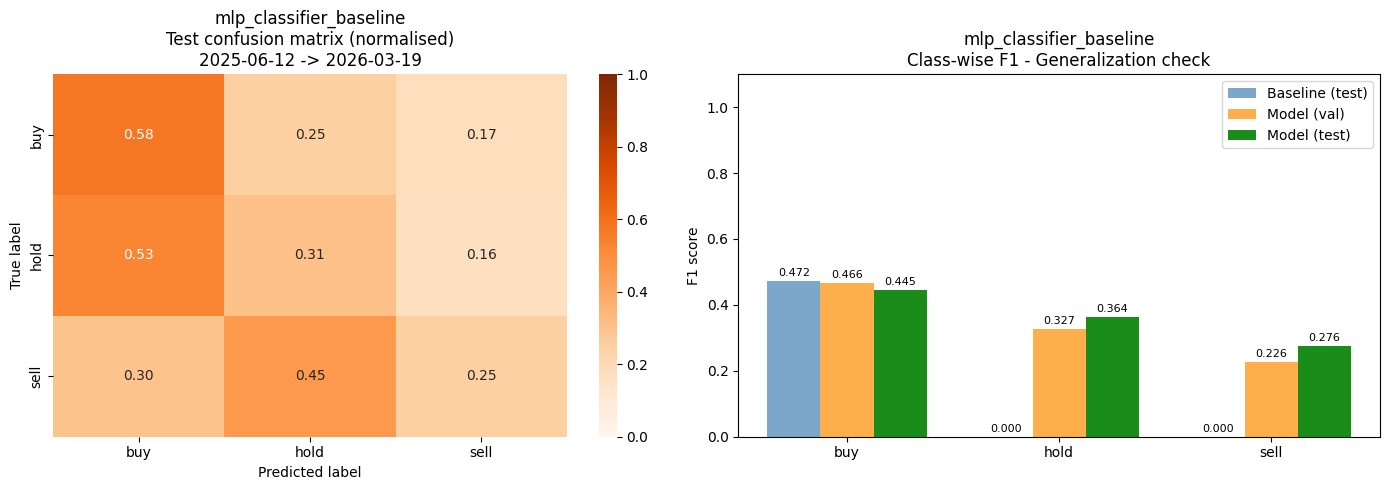

In [23]:
classes = ['buy', 'hold', 'sell']
test_start_str2 = meta_test['date'].min().date()
test_end_str2   = meta_test['date'].max().date()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Normalised confusion matrix (test)
cm_array = np.array(test_metrics['confusion_matrix'], dtype=float)
cm_norm  = cm_array / cm_array.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Oranges',
    xticklabels=classes, yticklabels=classes,
    vmin=0, vmax=1, ax=axes[0],
)
axes[0].set_title(f'{MODEL_NAME}\nTest confusion matrix (normalised)\n{test_start_str2} -> {test_end_str2}')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Plot 2: Class-wise F1 - three series
x = np.arange(len(classes))
width = 0.25
baseline_test_f1 = [baseline_results['test']['per_class'][c]['f1'] for c in classes]
model_val_f1     = [val_metrics['per_class'][c]['f1']               for c in classes]
model_test_f1    = [test_metrics['per_class'][c]['f1']              for c in classes]

b1 = axes[1].bar(x - width,   baseline_test_f1, width, label='Baseline (test)', color='steelblue',  alpha=0.7)
b2 = axes[1].bar(x,           model_val_f1,     width, label='Model (val)',     color='darkorange', alpha=0.7)
b3 = axes[1].bar(x + width,   model_test_f1,    width, label='Model (test)',    color='green',      alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_ylim(0, 1.10)
axes[1].set_ylabel('F1 score')
axes[1].set_title(f'{MODEL_NAME}\nClass-wise F1 - Generalization check')
axes[1].legend()
for bars in [b1, b2, b3]:
    axes[1].bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.show()


# 10. Standardized Result Packaging and Saving

## 10.1 Build the Standardized Result Dictionary

Assembles all evaluation outputs into the uniform result schema defined in the PRD (Section 11), so this notebook's artifacts can be loaded and compared alongside any other model notebook's artifacts without custom parsing.

Construct the `results` dict with the following top-level keys:
- `model_name` — value of `MODEL_NAME`.
- `model_type` — full scikit-learn class path string (e.g. `sklearn.neural_network.MLPClassifier`), derived programmatically from the estimator.
- `hyperparameters` — dict from `pipeline.named_steps["clf"].get_params()`, converted to Python-native types (no `numpy.int64`, `numpy.float32`, etc.) to ensure JSON serializability.
- `data` — dict with keys: `train_start`, `train_end`, `val_start`, `val_end`, `test_start`, `test_end` (ISO-format date strings), and `n_train`, `n_val`, `n_test` (integer row counts).
- `class_labels` — fixed list `["buy", "hold", "sell"]`.
- `baseline` — `baseline_results` dict (already contains `val` and `test` sub-dicts).
- `metrics` — dict with `val` set to `val_metrics` and `test` set to `test_metrics`.
- `notes` — dict with `threshold_buy` (0.05), `threshold_sell` (-0.05), `label_definition`, and `class_weight_strategy`.

Print the top-level keys of `results` as a confirmation.

**Input:** All previously computed variables.  
**Output:** `results` dict ready for serialization.

In [24]:
def _to_native(obj):
    if isinstance(obj, dict):
        return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_to_native(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (pd.Timestamp, datetime.datetime, datetime.date)):
        return obj.isoformat()
    return obj

clf_step     = pipeline.named_steps['clf']
model_module = clf_step.__class__.__module__
model_class  = clf_step.__class__.__name__

results = {
    'model_name':      MODEL_NAME,
    'model_type':      f'{model_module}.{model_class}',
    'hyperparameters': _to_native(clf_step.get_params()),
    'data': {
        'train_start': meta_train['date'].min().isoformat(),
        'train_end':   meta_train['date'].max().isoformat(),
        'val_start':   meta_val['date'].min().isoformat(),
        'val_end':     meta_val['date'].max().isoformat(),
        'test_start':  meta_test['date'].min().isoformat(),
        'test_end':    meta_test['date'].max().isoformat(),
        'n_train':     int(len(X_train)),
        'n_val':       int(len(X_val)),
        'n_test':      int(len(X_test)),
    },
    'class_labels': ['buy', 'hold', 'sell'],
    'baseline':     _to_native(baseline_results),
    'metrics': {
        'val':  _to_native(val_metrics),
        'test': _to_native(test_metrics),
    },
    'notes': {
        'threshold_buy':        0.05,
        'threshold_sell':       -0.05,
        'label_definition':     'buy if fwd_ret_20d >= 0.05; sell if fwd_ret_20d <= -0.05; hold otherwise',
        'class_weight_strategy': 'none - MLPClassifier does not support class_weight; macro F1 and balanced accuracy are the primary imbalance checks',
    },
}

print('results keys:', list(results.keys()))


results keys: ['model_name', 'model_type', 'hyperparameters', 'data', 'class_labels', 'baseline', 'metrics', 'notes']


## 10.2 Save Metrics JSON Artifact

Serializes the `results` dict to a JSON file so downstream steps can load and compare all candidate models programmatically.

- Create the output directory (`OUTPUT_DIR`) if it does not already exist.
- Write `results` to `{OUTPUT_DIR}/{MODEL_NAME}_metrics.json` using `json.dump` with `indent=2`.
- Use a custom JSON encoder (or pre-convert all values) to handle any remaining numpy scalar types, pandas `Timestamp` objects, or Python `datetime` values.
- Print the full path of the saved file as confirmation.

**Input:** `results`, `OUTPUT_DIR`, `MODEL_NAME`.  
**Output:** `{MODEL_NAME}_metrics.json` file on disk; printed confirmation.

In [25]:
class _NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (pd.Timestamp, datetime.datetime, datetime.date)):
            return obj.isoformat()
        return super().default(obj)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
json_path = OUTPUT_DIR / f'{MODEL_NAME}_metrics.json'

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, cls=_NumpyEncoder)

print(f'Metrics JSON saved to:\n  {json_path.resolve()}')


Metrics JSON saved to:
  C:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python\1‑month-direction-classifier\3_evaluate_model\mlp_classifier_baseline_metrics.json


## 10.3 Save Test-Set Prediction CSV (Optional)

Conditionally writes a per-row prediction file for the test set, controlled by the `SAVE_PREDICTIONS_CSV` configuration flag.

If `SAVE_PREDICTIONS_CSV` is `True`:
- Assemble a DataFrame from `meta_test` (`symbol`, `date`) combined with `y_test` (renamed `y_true`) and `y_test_pred` (renamed `y_pred`).
- If `y_test_proba` is not `None`, add columns `proba_buy`, `proba_hold`, `proba_sell` using the class order from `pipeline.classes_`.
- Save to `{OUTPUT_DIR}/{MODEL_NAME}_test_predictions.csv` (no index).
- Print the saved path and row count.

If `SAVE_PREDICTIONS_CSV` is `False`: print a skip notice.

**Input:** `meta_test`, `y_test`, `y_test_pred`, `y_test_proba`, `SAVE_PREDICTIONS_CSV`, `OUTPUT_DIR`, `MODEL_NAME`.  
**Output:** Optional CSV file on disk; printed status.

In [26]:
if SAVE_PREDICTIONS_CSV:
    pred_df = meta_test.copy()
    pred_df['y_true'] = y_test.values
    pred_df['y_pred'] = y_test_pred

    if y_test_proba is not None:
        class_order = pipeline.classes_.tolist()
        for i, cls in enumerate(class_order):
            pred_df[f'proba_{cls}'] = y_test_proba[:, i]

    csv_path = OUTPUT_DIR / f'{MODEL_NAME}_test_predictions.csv'
    pred_df.to_csv(csv_path, index=False)
    print(f'Test predictions CSV saved to:\n  {csv_path.resolve()}')
    print(f'  Rows: {len(pred_df):,}')
else:
    print('SAVE_PREDICTIONS_CSV = False - skipping prediction CSV.')


Test predictions CSV saved to:
  C:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python\1‑month-direction-classifier\3_evaluate_model\mlp_classifier_baseline_test_predictions.csv
  Rows: 579


## 10.4 Save Trained Model Pickle (Optional)

Conditionally pickles the fitted pipeline, controlled by the `SAVE_MODEL_PICKLE` configuration flag.

If `SAVE_MODEL_PICKLE` is `True`:
- Open `{OUTPUT_DIR}/{MODEL_NAME}_model.pkl` in binary-write mode and call `pickle.dump(pipeline, f)`.
- Print the saved path and approximate file size.

If `SAVE_MODEL_PICKLE` is `False`: print a skip notice.

> **Note:** Pickle files are not portable across Python or scikit-learn versions. Treat them as local research artifacts only.

**Input:** Fitted `pipeline`, `SAVE_MODEL_PICKLE`, `OUTPUT_DIR`, `MODEL_NAME`.  
**Output:** Optional `.pkl` file on disk; printed status.

In [27]:
if SAVE_MODEL_PICKLE:
    pkl_path = OUTPUT_DIR / f'{MODEL_NAME}_model.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(pipeline, f)
    file_size_kb = pkl_path.stat().st_size / 1024
    print(f'Model pickle saved to:\n  {pkl_path.resolve()}')
    print(f'  File size: {file_size_kb:.1f} KB')
else:
    print('SAVE_MODEL_PICKLE = False - skipping model pickle.')


Model pickle saved to:
  C:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python\1‑month-direction-classifier\3_evaluate_model\mlp_classifier_baseline_model.pkl
  File size: 159.7 KB


# 11. Summary and Next Steps

## 11.1 Notebook Summary

Prints a human-readable end-of-notebook summary recapping the key results from this evaluation run.

Summarize:
- `MODEL_NAME` and the model class used.
- Key configured hyperparameters.
- Training data period and test data period.
- Macro F1 and per-class (buy / sell / hold) F1 for: baseline (val), model (val), baseline (test), model (test) — displayed as a compact comparison table.
- Lift over baseline: absolute and relative improvement in macro F1 on the test set.
- Path to the saved JSON artifact and any other saved files.

**Input:** All previously computed metric variables.  
**Output:** Printed summary (no new variables or files).

In [28]:
print('=' * 65)
print('EVALUATION SUMMARY')
print('=' * 65)

clf_step = pipeline.named_steps['clf']
print(f'  Model name  : {MODEL_NAME}')
print(f'  Model class : {clf_step.__class__.__module__}.{clf_step.__class__.__name__}')
print('\n  Key hyperparameters:')
for k, v in MODEL_HYPERPARAMS.items():
    print(f'    {k:<24} = {v}')

print(f'\n  Training period : {results["data"]["train_start"]} -> {results["data"]["train_end"]}  (n={results["data"]["n_train"]:,})')
print(f'  Test period     : {results["data"]["test_start"]} -> {results["data"]["test_end"]}  (n={results["data"]["n_test"]:,})')

bv = baseline_results['val']
bt = baseline_results['test']
print(f'\n  {"Metric":<22} {"BL(val)":>9} {"M(val)":>9} {"BL(test)":>9} {"M(test)":>9}')
print('  ' + '-' * 60)
for key in ['macro_f1', 'weighted_f1', 'balanced_accuracy']:
    print(f'  {key:<22} {bv[key]:>9.4f} {val_metrics[key]:>9.4f} {bt[key]:>9.4f} {test_metrics[key]:>9.4f}')

print('\n  Per-class F1 (test):')
for cls in ['buy', 'hold', 'sell']:
    bf1 = bt['per_class'][cls]['f1']
    mf1 = test_metrics['per_class'][cls]['f1']
    print(f'    {cls:<6}  baseline={bf1:.4f}  model={mf1:.4f}')

baseline_test_macro = bt['macro_f1']
model_test_macro    = test_metrics['macro_f1']
abs_lift = model_test_macro - baseline_test_macro
rel_lift = (abs_lift / baseline_test_macro * 100) if baseline_test_macro > 0 else float('nan')
print(f'\n  Lift over baseline (test macro F1):')
print(f'    Absolute : {abs_lift:+.4f}')
print(f'    Relative : {rel_lift:+.1f}%')

print(f'\n  Saved artifacts:')
print(f'    JSON metrics  : {(OUTPUT_DIR / (MODEL_NAME + "_metrics.json")).resolve()}')
if SAVE_PREDICTIONS_CSV:
    print(f'    Predictions   : {(OUTPUT_DIR / (MODEL_NAME + "_test_predictions.csv")).resolve()}')
if SAVE_MODEL_PICKLE:
    print(f'    Model pickle  : {(OUTPUT_DIR / (MODEL_NAME + "_model.pkl")).resolve()}')
print('=' * 65)


EVALUATION SUMMARY
  Model name  : mlp_classifier_baseline
  Model class : sklearn.neural_network._multilayer_perceptron.MLPClassifier

  Key hyperparameters:
    hidden_layer_sizes       = (64, 32)
    activation               = relu
    solver                   = adam
    alpha                    = 0.001
    batch_size               = 64
    learning_rate_init       = 0.001
    max_iter                 = 500
    early_stopping           = False
    random_state             = 42
    class_weight             = n/a - MLPClassifier does not support class_weight; monitor macro F1 and balanced accuracy

  Training period : 2021-02-01T00:00:00 -> 2024-09-03T00:00:00  (n=2,709)
  Test period     : 2025-06-12T00:00:00 -> 2026-03-19T00:00:00  (n=579)

  Metric                   BL(val)    M(val)  BL(test)   M(test)
  ------------------------------------------------------------
  macro_f1                  0.1731    0.3398    0.1574    0.3617
  weighted_f1               0.1820    0.3470    0.146

## 11.2 How to Evaluate a Different Model (Template Instructions)

**To evaluate a different candidate model, follow these steps:**

1. **Duplicate this notebook** and rename it (e.g. `evaluate_model_2.ipynb`).
2. **In Section 2.1 (Configuration):** change `MODEL_NAME` to a unique identifier for the new model (e.g. `mlp_classifier_baseline`).
3. **In Section 7.1 (Model Configuration):** replace the estimator class and its hyperparameters. Update `MODEL_HYPERPARAMS` accordingly.
4. **In Section 7.2 (Pipeline):** add or remove the `StandardScaler` step depending on whether the new model requires feature scaling.
5. **Run all cells top to bottom.** All file names, metrics, and artifacts will automatically use the new `MODEL_NAME`.

**Candidate models and scaling requirements:**

| Model | Requires Scaling |
|---|---|
| `LogisticRegression` | Yes |
| `LinearSVC` | Yes |
| `MLPClassifier` | Yes |
| `RandomForestClassifier` | No |
| `ExtraTreesClassifier` | No |
| `HistGradientBoostingClassifier` | No |

**Next steps beyond this template:**
- A separate tuning notebook will use `TimeSeriesSplit`-based `RandomizedSearchCV` on the top 2 models identified from comparing `{MODEL_NAME}_metrics.json` artifacts.
- A comparison aggregation cell/notebook can load all JSON artifacts and produce a ranked leaderboard.
- Deeper error analysis (regime-based slices, SHAP feature importance) can be added once a final model is selected.